In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("cleaned_dataset.csv", encoding="latin1")

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,TOTAL_VALUE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,86130.00
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,94040.60
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,159257.94
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,168601.50
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,255058.23


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 2823
Columns : 26
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2     

In [5]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
TOTAL_VALUE            0
dtype: int64

In [6]:
df["TOTAL_VALUE"] = df["QUANTITYORDERED"] * df["PRICEEACH"]

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,TOTAL_VALUE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,2871.00
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,2765.90
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,3884.34
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,3746.70
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,4900.00


In [7]:
total_revenue = df["SALES"].sum()
avg_sales = df["SALES"].mean()
total_orders = df["ORDERNUMBER"].nunique()
total_customers = df["CUSTOMERNAME"].nunique()

print("Total Revenue :", total_revenue)
print("Average Sales :", avg_sales)
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)

Total Revenue : 10032628.85
Average Sales : 3553.889071909316
Total Orders : 307
Total Customers : 92


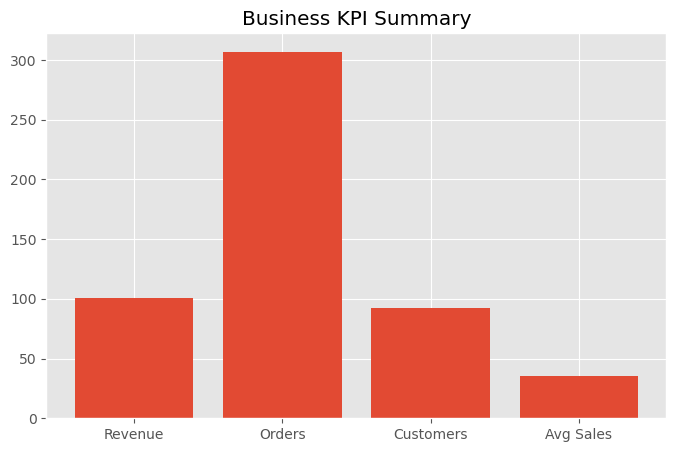

In [8]:
kpis = {
    "Revenue": total_revenue/100000,
    "Orders": total_orders,
    "Customers": total_customers,
    "Avg Sales": avg_sales/100
}

plt.figure(figsize=(8,5))
plt.bar(kpis.keys(), kpis.values())

plt.title("Business KPI Summary")
plt.show()

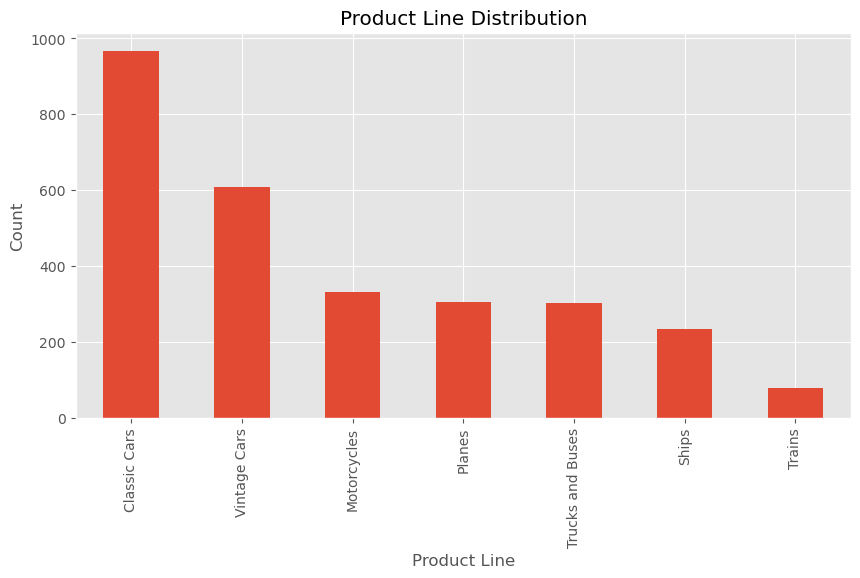

In [9]:
product_counts = df["PRODUCTLINE"].value_counts()

plt.figure(figsize=(10,5))
product_counts.plot(kind="bar")

plt.title("Product Line Distribution")
plt.xlabel("Product Line")
plt.ylabel("Count")

plt.show()

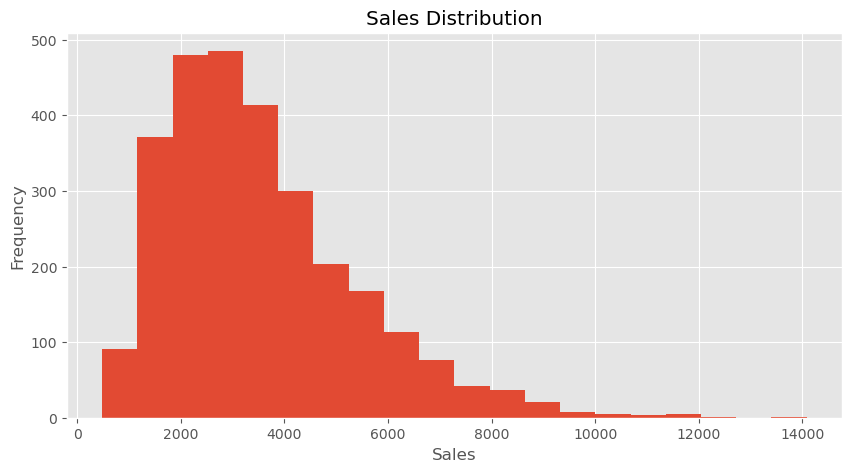

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["SALES"], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

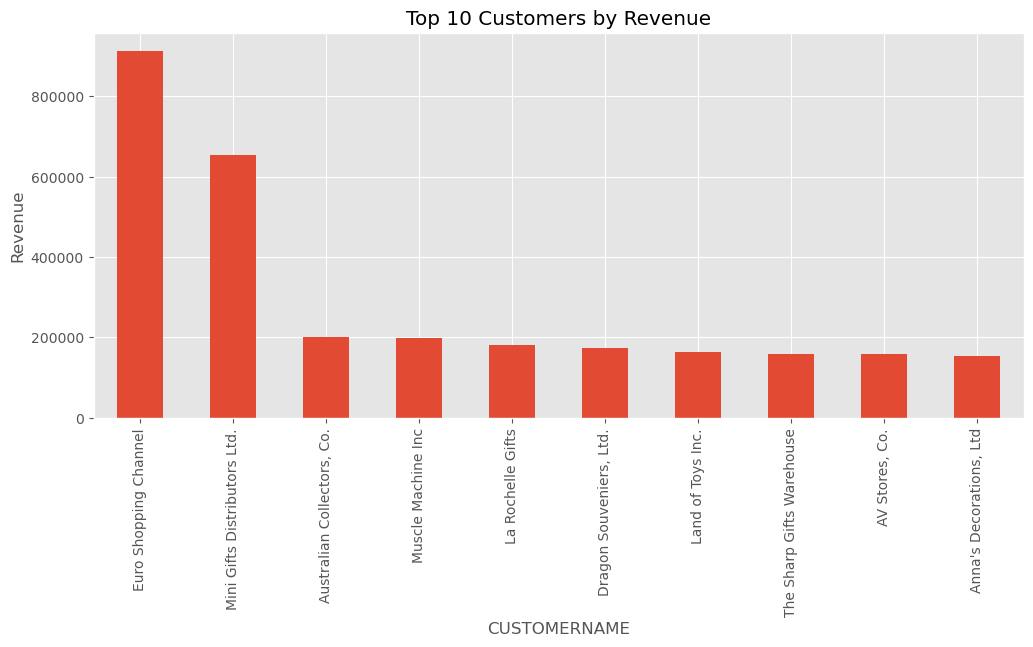

In [11]:
top_customers = df.groupby("CUSTOMERNAME")["SALES"].sum()

top_customers = top_customers.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.show()

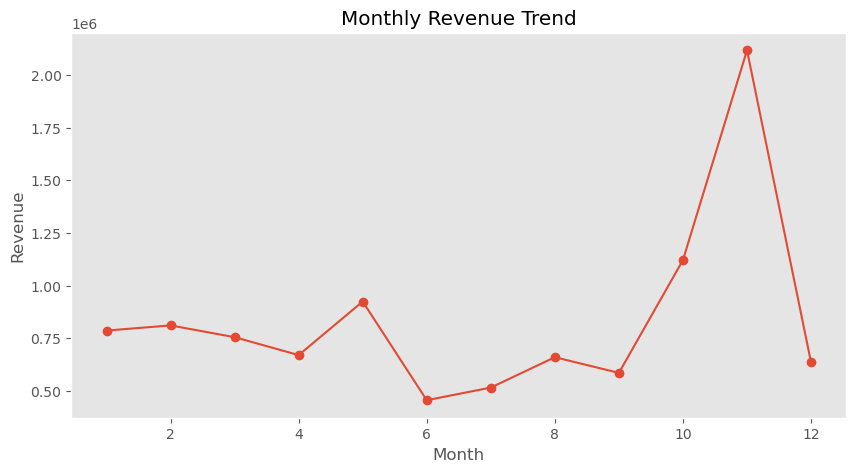

In [12]:
monthly_sales = df.groupby(
    "MONTH_ID"
)["SALES"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid()

plt.show()

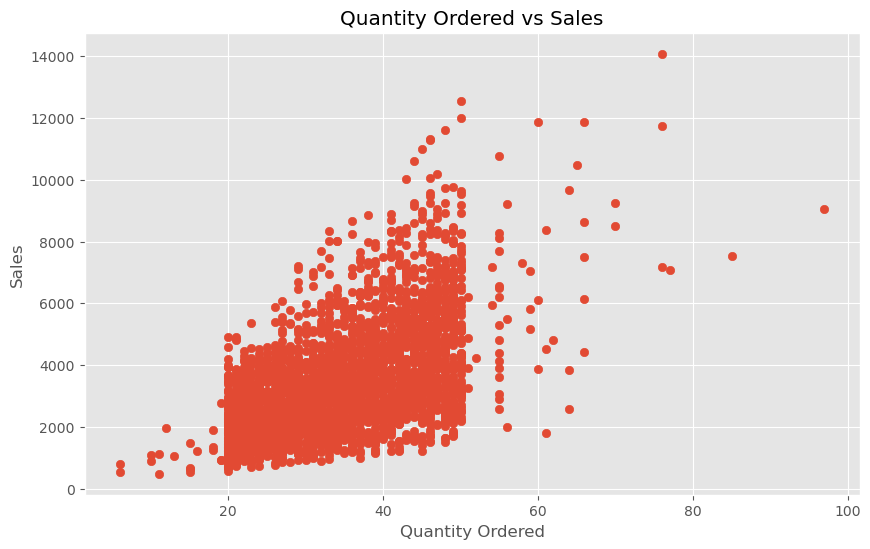

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["QUANTITYORDERED"],
    df["SALES"]
)

plt.title("Quantity Ordered vs Sales")
plt.xlabel("Quantity Ordered")
plt.ylabel("Sales")

plt.show()

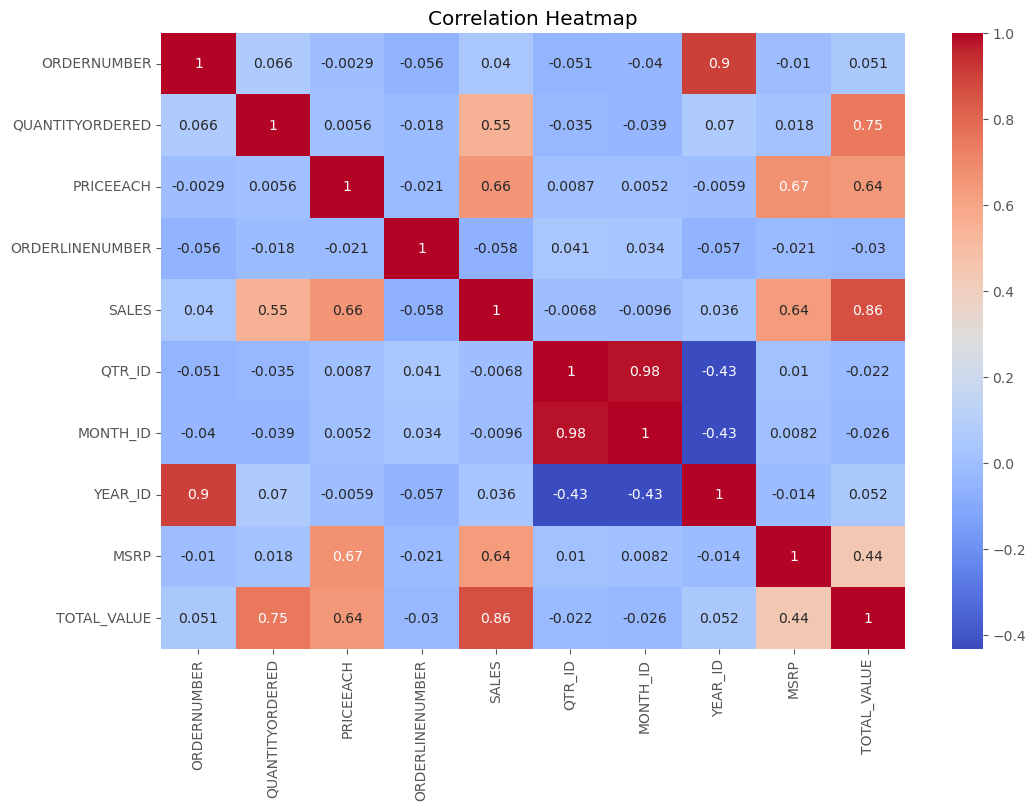

In [14]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()